# Rolling Statistics

This notebook analyzes rolling statistics of Rossmann daily sales to identify
short-term demand patterns, long-term trends, and sales volatility.

The analysis includes:
- 7-day rolling mean
- 30-day rolling mean
- 7-day rolling standard deviation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("../data/raw/train.csv")

train["Date"] = pd.to_datetime(train["Date"])

# Use only open stores
open_sales = train[train["Open"] == 1]

# Aggregate sales across stores by date
daily_sales = (
    open_sales
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

daily_sales.head()

/var/folders/vk/6pn68sk92z93wvsph2msbyvh0000gn/T/ipykernel_17632/773329247.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [2]:
daily_sales["Rolling_7_Day"] = (
    daily_sales["Sales"].rolling(window=7).mean()
)

daily_sales["Rolling_30_Day"] = (
    daily_sales["Sales"].rolling(window=30).mean()
)

daily_sales["Rolling_7_Day_STD"] = (
    daily_sales["Sales"].rolling(window=7).std()
)

daily_sales.head(35)

,Date,Sales,Rolling_7_Day,Rolling_30_Day,Rolling_7_Day_STD
0,2013-01-01,97235,NaN,NaN,NaN
1,2013-01-02,6949829,NaN,NaN,NaN
2,2013-01-03,6347820,NaN,NaN,NaN
3,2013-01-04,6638954,NaN,NaN,NaN
4,2013-01-05,5951593,NaN,NaN,NaN
5,2013-01-06,143904,NaN,NaN,NaN
6,2013-01-07,10826848,5.279455e+06,NaN,3.878024e+06
7,2013-01-08,8749437,6.515484e+06,NaN,3.284444e+06
8,2013-01-09,7746603,6.629308e+06,NaN,3.315663e+06
9,2013-01-10,7751485,6.829832e+06,NaN,3.338171e+06


In [3]:
daily_sales.head(35)

,Date,Sales,Rolling_7_Day,Rolling_30_Day,Rolling_7_Day_STD
0,2013-01-01,97235,NaN,NaN,NaN
1,2013-01-02,6949829,NaN,NaN,NaN
2,2013-01-03,6347820,NaN,NaN,NaN
3,2013-01-04,6638954,NaN,NaN,NaN
4,2013-01-05,5951593,NaN,NaN,NaN
5,2013-01-06,143904,NaN,NaN,NaN
6,2013-01-07,10826848,5.279455e+06,NaN,3.878024e+06
7,2013-01-08,8749437,6.515484e+06,NaN,3.284444e+06
8,2013-01-09,7746603,6.629308e+06,NaN,3.315663e+06
9,2013-01-10,7751485,6.829832e+06,NaN,3.338171e+06


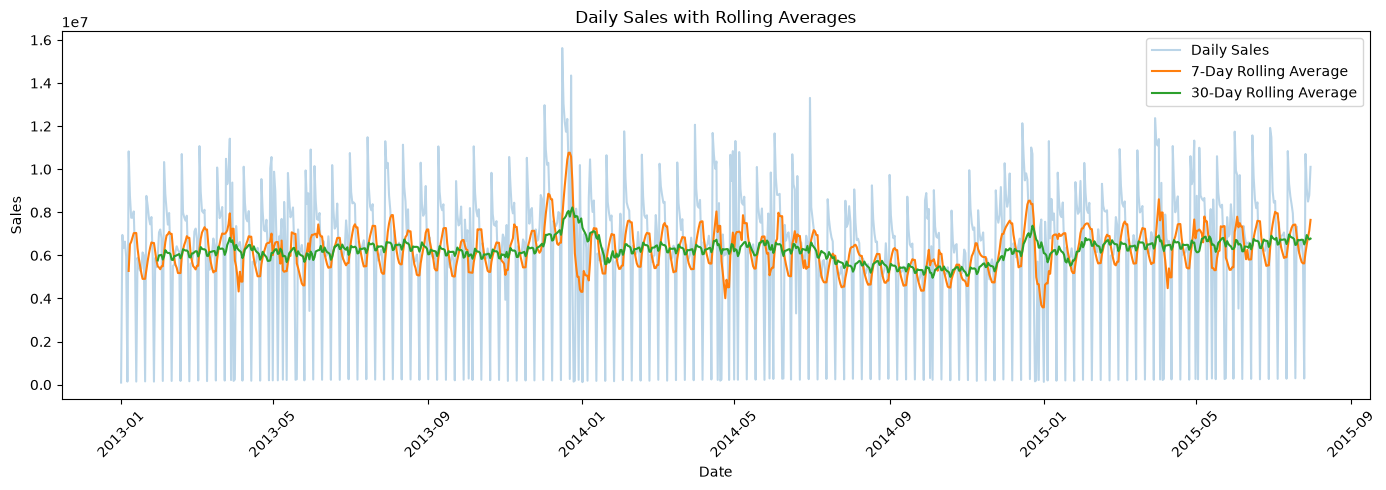

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    alpha=0.3,
    label="Daily Sales"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["Rolling_7_Day"],
    label="7-Day Rolling Average"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["Rolling_30_Day"],
    label="30-Day Rolling Average"
)

plt.title("Daily Sales with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

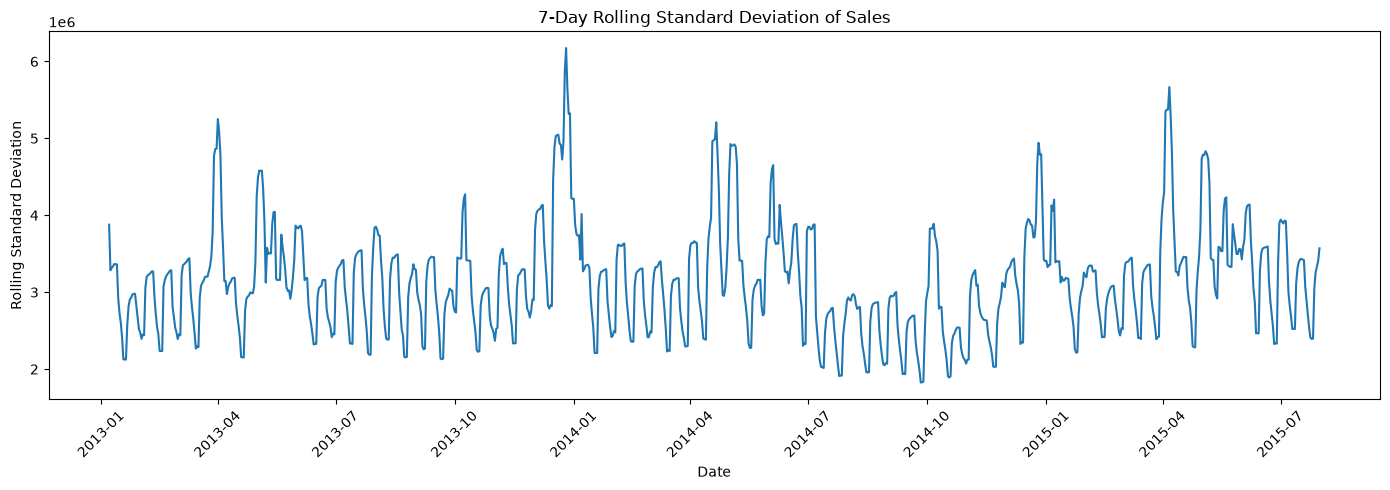

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Rolling_7_Day_STD"]
)

plt.title("7-Day Rolling Standard Deviation of Sales")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [6]:
rolling_summary = daily_sales[
    ["Sales", "Rolling_7_Day", "Rolling_30_Day", "Rolling_7_Day_STD"]
].describe()

rolling_summary

,Sales,Rolling_7_Day,Rolling_30_Day,Rolling_7_Day_STD
count,9.420000e+02,9.360000e+02,9.130000e+02,9.360000e+02
mean,6.234799e+06,6.231972e+06,6.229775e+06,3.135513e+06
std,3.130536e+06,9.640871e+05,4.690696e+05,6.998039e+05
min,9.723500e+04,3.588075e+06,4.962116e+06,1.824857e+06
25%,5.675832e+06,5.505244e+06,6.010818e+06,2.624201e+06
50%,6.580354e+06,6.195225e+06,6.262592e+06,3.086869e+06
75%,8.174899e+06,6.938918e+06,6.490525e+06,3.444636e+06
max,1.562355e+07,1.076733e+07,8.227152e+06,6.173953e+06


In [7]:
# Identify periods with unusually high sales volatility

volatility_threshold = daily_sales["Rolling_7_Day_STD"].quantile(0.90)

high_volatility = daily_sales[
    daily_sales["Rolling_7_Day_STD"] > volatility_threshold
]

print("High Volatility Threshold:", volatility_threshold)

high_volatility[[
    "Date",
    "Sales",
    "Rolling_7_Day_STD"
]].head(20)

High Volatility Threshold: 3938180.6149564134


,Date,Sales,Rolling_7_Day_STD
87,2013-03-29,213921,4.773132e+06
88,2013-03-30,9380402,4.861392e+06
89,2013-03-31,176418,4.864925e+06
90,2013-04-01,241076,5.250529e+06
91,2013-04-02,7362049,5.081251e+06
92,2013-04-03,6406442,4.774081e+06
93,2013-04-04,6496112,3.971083e+06
120,2013-05-01,200972,4.251533e+06
121,2013-05-02,9884371,4.492946e+06
122,2013-05-03,8967338,4.580280e+06


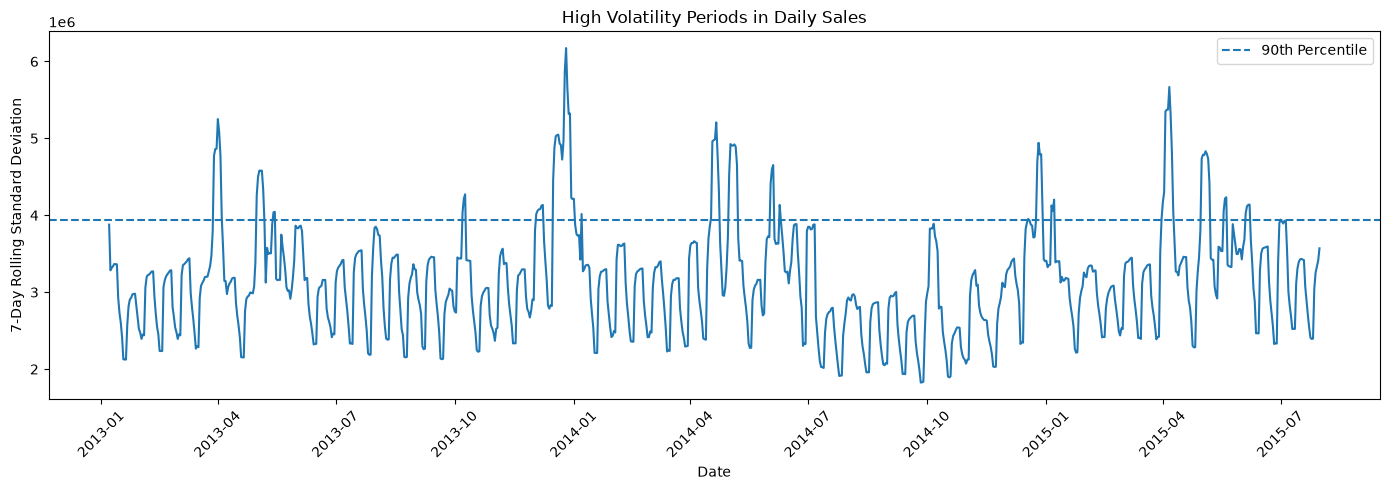

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Rolling_7_Day_STD"]
)

plt.axhline(
    volatility_threshold,
    linestyle="--",
    label="90th Percentile"
)

plt.title("High Volatility Periods in Daily Sales")
plt.xlabel("Date")
plt.ylabel("7-Day Rolling Standard Deviation")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()